In [42]:
import requests    
import numpy as np  
import pandas as pd 
import time
import re
from fake_useragent import UserAgent
from urllib.parse import urljoin
from bs4 import BeautifulSoup

### Парсим сайт магазина "Леонардо" и собираем информацию о полимерной глине

In [43]:
main_page_link = 'https://leonardo.ru/ishop/tree_3707276709/'

In [59]:
HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "ru-RU,ru;q=0.9,en;q=0.8",
}

##сбор ссылок на товары
def collect_links(page_url: str):
    r = requests.get(page_url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "lxml")

    cards = soup.select("div.goods-preview.goods-preview_full")

    links = []
    for card in cards:
        a = card.select_one("a.goods-preview__title[href]") or card.select_one("a.goods-preview__title[href]") \
            or card.select_one("a.goods-preview__top-wrapper[href]") \
            or card.select_one("a.goods-preview__showall-btn[href]")
        if not a:
            continue
        links.append(urljoin(page_url, a["href"]))

    links = list(dict.fromkeys(links))
    return links


links = collect_links(main_page_link)
len(links), links[:5]

(35,
 ['https://leonardo.ru/ishop/group_22074268412/',
  'https://leonardo.ru/ishop/group_66005045314/',
  'https://leonardo.ru/ishop/group_79702787134/',
  'https://leonardo.ru/ishop/group_52014687512/',
  'https://leonardo.ru/ishop/group_26648931602/'])

In [78]:
def parse_int(text):
    if not text:
        return None
    digits = "".join(ch for ch in text if ch.isdigit())
    return int(digits) if digits else None

def parse_float(text):
    if not text:
        return None
    text = text.replace(",", ".").strip()
  
    cleaned = "".join(ch for ch in text if ch.isdigit() or ch == ".")
    return float(cleaned) if cleaned else None

def parse_product_detail(product_url: str):
    r = requests.get(product_url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "lxml")

    #название
    title = soup.select_one("h1.card__title")
    title = title.get_text(" ", strip=True) if title else None

    #рейтинг
    rating = soup.select_one("div.goods__rating")
    rating = parse_float(rating.get_text(" ", strip=True)) if rating else None

    #отзывы 
    reviews = soup.select_one("a.link-to-reviews")
    reviews_count = parse_int(reviews.get_text(" ", strip=True)) if reviews else None

    #цена
    price = soup.select_one("p.price")
    price_rub = parse_int(price.get_text(" ", strip=True)) if price else None

    #производитель и ссылка на бренд
    brand = soup.select_one('a[href^="/ishop/brands/"].blue-link')
    brand = brand.get_text(" ", strip=True) if brand else None

    # Характеристики
    specs = {}
    ths = soup.select("div.card__about-th")
    for th in ths:
        key = th.get_text(" ", strip=True).strip(":")
        td = th.find_next_sibling("div", class_="card__about-td")
        if td:
            val = td.get_text(" ", strip=True)
            specs[key] = val

    country = specs.get("Страна происхождения") 
    weight_g = parse_int(specs.get("Вес, г"))

    #список цветов
    colors = []

    for el in soup.select("[data-color], [aria-label*='цвет'], [title*='цвет'], [class*='color']"):
        lab = el.get("data-color") or el.get("aria-label") or el.get("title")
        if lab:
            colors.append(lab.strip())
    colors = list(dict.fromkeys(colors))   

    return {
        "Название": title,
        "Цена, рубли": price_rub,
        "Рейтинг": rating,
        "Число отзывов": reviews_count,
        "Бренд": brand,
        "Страна происхождения": country,
        "Вес, г": weight_g,
        "Цвета": ", ".join(colors) if colors else None,
        "Число цветов": len(colors)
    }

In [79]:
import time, random
import pandas as pd

def crawl_details(urls, sleep=(0.3, 0.8)):
    rows = []
    for i, u in enumerate(urls, 1):
        try:
            det = parse_product_detail(u)
            det["url"] = u
            rows.append(det)
        except Exception as e:
            rows.append({"url": u, "detail_error": str(e)})
        if i % 20 == 0:
            print("done", i)
        time.sleep(random.uniform(*sleep))
    return rows

In [80]:
data = crawl_details(links, sleep=(0.3, 0.8))

done 20


In [81]:
df = pd.DataFrame(data)

In [82]:
df

,Назание,"Цена, рубли",Рейтинг,Число отзывов,Бренд,Страна происхождения,"Вес, г",Цвета,Число цветов,url
0,"""Craft&Clay"" полимерная глина CCH 52 г",219,3.9,28,"""Craft&Clay""",Россия,52.0,"1001 белый, 1002 черный, 1003 полупрозрачный, ...",77,https://leonardo.ru/ishop/group_22074268412/
1,"""Craft&Clay"" полимерная глина CCH гламур 52 г",219,4.0,2,"""Craft&Clay""",Россия,52.0,"1501 белый, 1502 черный, 1503 алый, 1504 синий...",10,https://leonardo.ru/ishop/group_66005045314/
2,"""Craft&Clay"" полимерная глина для лепки кукол ...",219,3.0,4,"""Craft&Clay""",Россия,52.0,"1701 миндальное молоко, 1702 фарфор, 1703 вани...",10,https://leonardo.ru/ishop/group_79702787134/
3,"""Craft&Clay"" полимерная глина CCH эффект матов...",259,4.8,6,"""Craft&Clay""",Россия,50.0,"1401 белый, 1402 нежно-розовый, 1403 липовый м...",21,https://leonardo.ru/ishop/group_52014687512/
4,"""Craft&Clay"" полимерная глина CCH 250 г",799,4.6,25,"""Craft&Clay""",Россия,250.0,"1001 белый, 1002 черный, 1004 телесный светлый...",4,https://leonardo.ru/ishop/group_26648931602/
5,"""Craft&Clay"" полимерная глина CCH флуоресцентн...",219,4.5,6,"""Craft&Clay""",Россия,52.0,"1301 белый, 1302 голубой, 1303 зеленый, 1304 к...",8,https://leonardo.ru/ishop/group_23376789912/
6,"""Craft&Clay"" полимерная глина для лепки кукол ...",839,5.0,1,"""Craft&Clay""",Россия,250.0,"1801 миндальное молоко, 1802 фарфор, 1803 вани...",9,https://leonardo.ru/ishop/group_88436353954/
7,"""FIMO"" Soft полимерная глина 57 г",339,4.9,14,"""FIMO""",Германия,57.0,"8020-0 белый, 8020-10 лимонный, 8020-105 ванил...",40,https://leonardo.ru/ishop/group_7232627742/
8,"""FIMO"" Effect полимерная глина 57 г",339,5.0,4,"""FIMO""",Германия,57.0,"8010-08 перламутровый металлик, 8010-11 золото...",39,https://leonardo.ru/ishop/group_8010200262/
9,"""Sculpey"" III полимерная глина S302 57 г",219,5.0,2,"""Sculpey""",Соединенные Штаты,57.0,"033 рыжий, 042 черный, 053 шоколадный, 063 гол...",55,https://leonardo.ru/ishop/group_6867123202/


### NLP (датасет с отзывами на кинофильмы)

In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

nltk.download("stopwords") 
en_stop = stopwords.words("english")
df = pd.read_csv("C:/Users/Anastasia_Golubova/Yandex.Disk/OTUS_Networks/Parsing/IMDB Dataset.csv")

vectorizer = TfidfVectorizer(
    max_df=0.9,     
    min_df=5,        
    ngram_range=(1,2),  
    stop_words=en_stop
)

X_tfidf = vectorizer.fit_transform(df["review"])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Anastasia_Golubova\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package stopwords is already up-to-date!


In [122]:
df["sentiment"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"]
)

In [124]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

model = LogisticRegression(max_iter=1000)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {'C': [0.001,0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
}

grid_LG = GridSearchCV(model,param_grid,cv=cv)
grid_LG.fit(X_train, y_train)

best_model_LG = grid_LG.best_estimator_

best_model_LG.fit(X_train,y_train)
print(f'Best parameters: {grid_LG.best_params_}')

Best parameters: {'C': 10, 'solver': 'liblinear'}


In [125]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

y_pred = best_model_LG.predict(X_train)
report = classification_report(y_train, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       1.00      1.00      1.00     20000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



              precision    recall  f1-score   support

           0       0.92      0.91      0.91      5000
           1       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

LG,ROC curve (area = 0.97)


Text(0, 0.5, 'tpr')

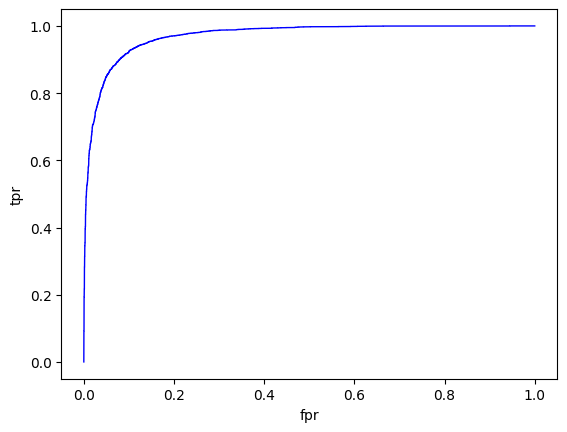

In [126]:
import matplotlib.pyplot as plt

y_pred = best_model_LG.predict(X_test)
y_prob = best_model_LG.predict_proba(X_test)[:, 1]
report = classification_report(y_test, y_pred)
print(report)

roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
print(f'LG,ROC curve (area = {roc_auc:.2f})')
plt.plot(fpr, tpr, color='blue', lw=1)
plt.xlabel('fpr')
plt.ylabel('tpr')

In [127]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
coefs = best_model_LG.coef_.ravel()

coef_df = pd.DataFrame({"term": feature_names, "coef": coefs})

top_pos = coef_df.sort_values("coef", ascending=False).head(50)
top_neg = coef_df.sort_values("coef", ascending=True).head(50)

top_pos, top_neg

(                term       coef
 68827          great  13.025133
 50581      excellent  13.011352
 117432       perfect  11.195440
 7092         amazing   9.800387
 174897     wonderful   9.696299
 73522      hilarious   9.085487
 15477           best   8.759573
 21997      brilliant   8.685494
 93281          loved   8.639671
 46584      enjoyable   8.204823
 152884        superb   8.147283
 62209            fun   8.057802
 46642        enjoyed   8.005203
 53923       favorite   7.967117
 106865      must see   7.918488
 160436         today   7.849156
 112055      one best   7.827050
 172577    well worth   7.346220
 35             10 10   7.290494
 62430       funniest   7.138362
 117545     perfectly   6.878581
 73447         highly   6.840878
 53266      fantastic   6.676661
 43293            dvd   6.534667
 63513            gem   6.520896
 149483         still   6.518508
 175013   wonderfully   6.429897
 77832     incredible   6.418106
 165568        unique   6.396186
 47113   e

### Вывод: наибольшие коэффициенты в модели (то есть наиболее важные признаки для классификации отзывов) получили слова, дающие какую-то характеристику: great (хороший), excellent (превосходный), worst (худший), awful (ужасный) и тд, что логично и легко интерпретируемо.